# Import libraries

In [5]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
# import getFamaFrenchFactors as gff
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
# yf.pdr_override()
import pulp
from sklearn.preprocessing import LabelEncoder
import pandas_datareader.data as reader
import yfinance as yf
import pandas as pd
import requests
# import getFamaFrenchFactors as gff
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *
import getFamaFrenchFactors as gff
import time
import requests
from openpyxl import load_workbook
import importlib
# yf.pdr_override()

# Import all project functionalities

In [6]:
from multifactor_functionalities import *
import multifactor_functionalities as mff

# Set up the raw data

In [7]:
#import stock data
new_data=pd.read_csv('daat.csv')
new_data.drop(columns='PERMNO',inplace=True)
new_data.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
price_monthly_data=new_data.drop(columns='RET')
new_monthly_data=new_data.drop(columns='PRC')
price_monthly_data
price_monthly_data=price_monthly_data.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
new_monthly_data
new_monthly_data=new_monthly_data.pivot_table(index='Date', columns='Ticker', values='RET', aggfunc='first')
#import sp500 data
index=pd.read_csv('spy_data.csv')
indexgspc=index.copy()
indexgspc.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc.set_index('Date',inplace=True)
indexgspc.index = pd.to_datetime(indexgspc.index)
indexgspc=indexgspc.dropna()

# Analysis here and run simulations here

In [5]:
oos1_list = monte_carlo_simulation_s(1,1,1,0.3,'stop',3,15,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2015-01-01'))




True
2010-02-01


True
2011-02-01


True
2012-02-01


Column 'GNRC' could not be converted to float.
Column 'PNR' could not be converted to float.
True
2013-02-01


Column 'KMI' could not be converted to float.
Column 'NWS' could not be converted to float.
Column 'NWSA' could not be converted to float.
Column 'PNR' could not be converted to float.
True
2014-02-01


In [4]:
oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,0,0,'stop',3,20,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2015-01-01'))




Column 'CMCSA' could not be converted to float.
Column 'EQIX' could not be converted to float.
Column 'KMX' could not be converted to float.
Column 'NWS' could not be converted to float.
Column 'WBD' could not be converted to float.
True


ValueError: matrices are not aligned

In [ ]:
backtest = pd.DataFrame(columns=['SPY'])
for i in range(1, 6):
    if i == 1:
        oos1_list = monte_carlo_simulation_s(3,1,0.7,0.7,'stop',3,15,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2014-12-31'))
        backtest['1|0.7|0.7']= oos1_list#['Optimized Portfolio']
    if i == 2:
        oos1_list = monte_carlo_simulation_s(3,1,1,0.1,'stop',3,15,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2014-12-31'))
        backtest['1|1|0.1']= oos1_list#['Optimized Portfolio']
        display(backtest)
    if i == 3:
        oos1_list = monte_carlo_simulation_s(3,1,0.8,0.2,'stop',3,15,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2014-12-31'))
        backtest['1|0.8|0.2']= oos1_list#['Optimized Portfolio']
    if i == 4:
        oos1_list, = monte_carlo_simulation_s (3,1,1,0.3,'stop',3,15,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2014-12-31'))
        backtest['1|1|0.3']= oos1_list#['Optimized Portfolio']
    if i == 5:
        oos1_list = monte_carlo_simulation_s(3,1,0,0,'stop',3,15,new_monthly_data,indexgspc,price_monthly_data,pd.to_datetime('2014-12-31'))
        backtest['1|0|0']= oos1_list#['Optimized Portfolio']
display(backtest)





True
2010-02-01


True
2011-02-01


True
2012-02-01


Column 'GNRC' could not be converted to float.
Column 'PNR' could not be converted to float.
True
2013-02-01


ValueError: matrices are not aligned

In [ ]:
vol_df = pd.DataFrame(columns=['Volatility'])
for i in range(1, 6):
    if i == 1:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,0.7,0.7,'rebalance',3,5,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2015-01-01'))
        rebalance_optimal_weights_appended = rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|.7|.7']= vol['Monthly Volatility']
    if i == 2:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,1,0.1,'rebalance',3,5,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2015-01-01'))
        rebalance_optimal_weights_appended = rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|1|.1']= vol['Monthly Volatility']
        display(vol_df)
    if i == 3:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,0.8,0.2,'rebalance',3,5,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2015-01-01'))
        rebalance_optimal_weights_appended = rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|.8|.2']= vol['Monthly Volatility']
    if i == 4:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,1,0.3,'rebalance',3,5,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2015-01-01'))
        rebalance_optimal_weights_appended = rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|1|.3']= vol['Monthly Volatility']
    if i == 5:
        oos1_list,oos1_list_yearly,oos1_average = monte_carlo_simulation(1,1,0,0,'rebalance',3,5,new_monthly_data,indexgspc,price_monthly_data, pd.to_datetime('2015-01-01'))
        rebalance_optimal_weights_appended = rebalanced_optimal_weights()
        vol = calculate_volatility(rebalance_optimal_weights_appended)
        vol_df['1|0|0']= vol['Monthly Volatility']
display(vol_df)



In [1]:
(vol_df)

NameError: name 'vol_df' is not defined

In [31]:
spy_v = pd.read_csv("SPY_V.csv")
spy_v.index = pd.to_datetime(spy_v.index)
spy_v = spy_v.loc[pd.to_datetime('2020-02-01'): pd.to_datetime('2024-12-01')]
spy_v = spy_v.resample('MS').mean()
spy_v['DATE SPY_V'] = spy_v['DATE SPY_V']/100
display(spy_v)

,DATE SPY_V
2020-02-01,0.196289
2020-03-01,0.577368
2020-04-01,0.414538
2020-05-01,0.308970
2020-06-01,0.311195
2020-07-01,0.268405
2020-08-01,0.228895
2020-09-01,0.276476
2020-10-01,0.294386
2020-11-01,0.249955


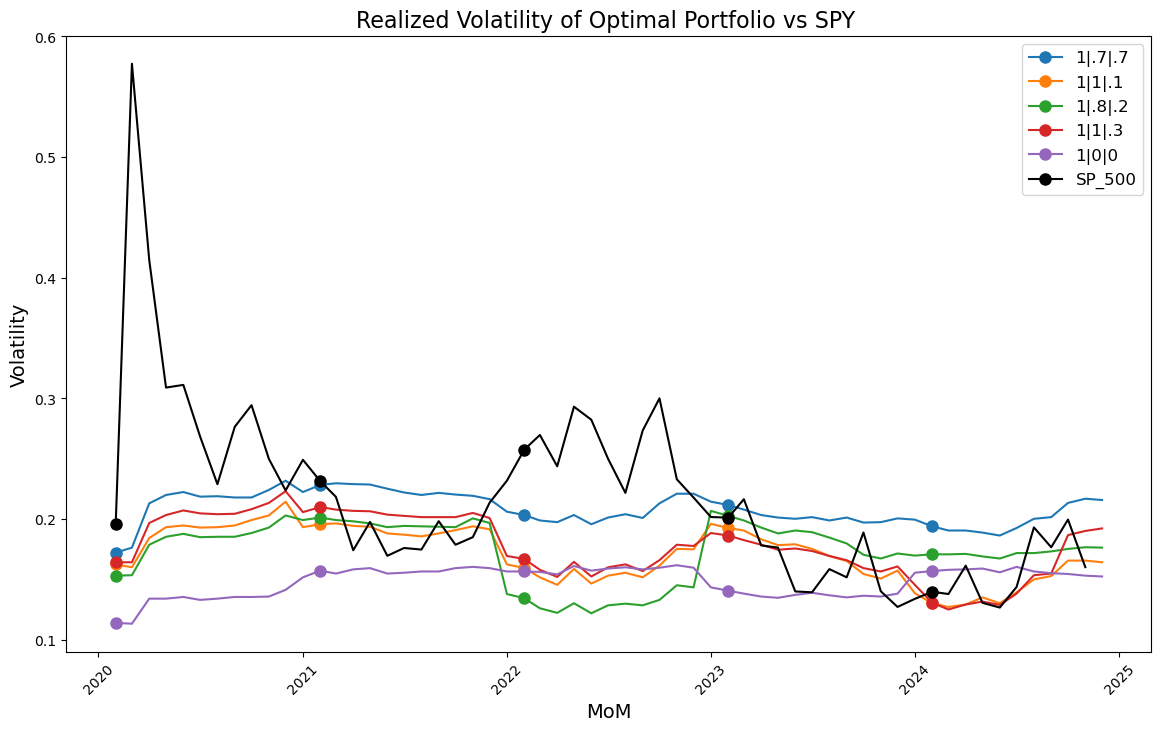

In [36]:
fig, ax = plt.subplots(figsize=(14, 8))

for col in vol_df.columns:
    ax.plot(vol_df.index, vol_df[col], label=col, marker = 'o', markersize=8, markevery=12)

ax.plot(spy_v.index, spy_v['DATE SPY_V'], label='SP_500',  color='black', marker = 'o', markersize=8, markevery=12)

ax.set_xlabel('MoM', fontsize=14)
ax.set_ylabel('Volatility', fontsize=14)
ax.set_title('Realized Volatility of Optimal Portfolio vs SPY ', fontsize=16)
ax.legend(fontsize=12)
plt.xticks(rotation=45)

plt.show()


In [20]:
import requests
import multifactor_functionalities as mff
mff.monte_carlo_simulation(22,1,0,0,'rebalance',3,5,new_monthly_data,indexgspc)

TypeError: monte_carlo_simulation() takes 4 positional arguments but 9 were given

In [25]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(22,1,0,0)

NameError: name 'requests' is not defined

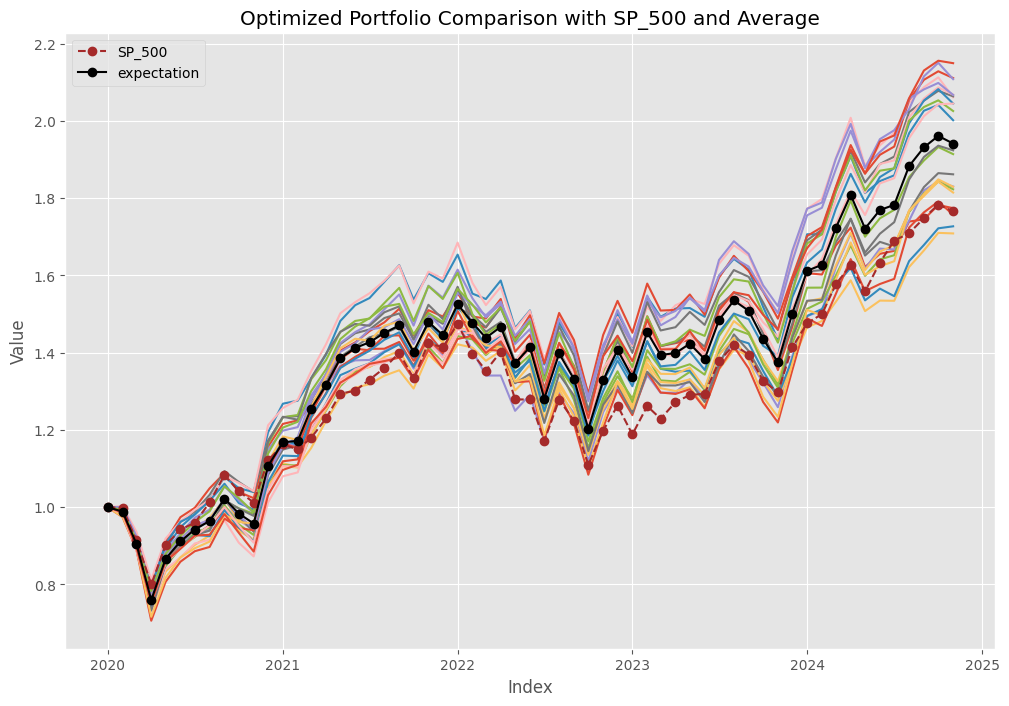

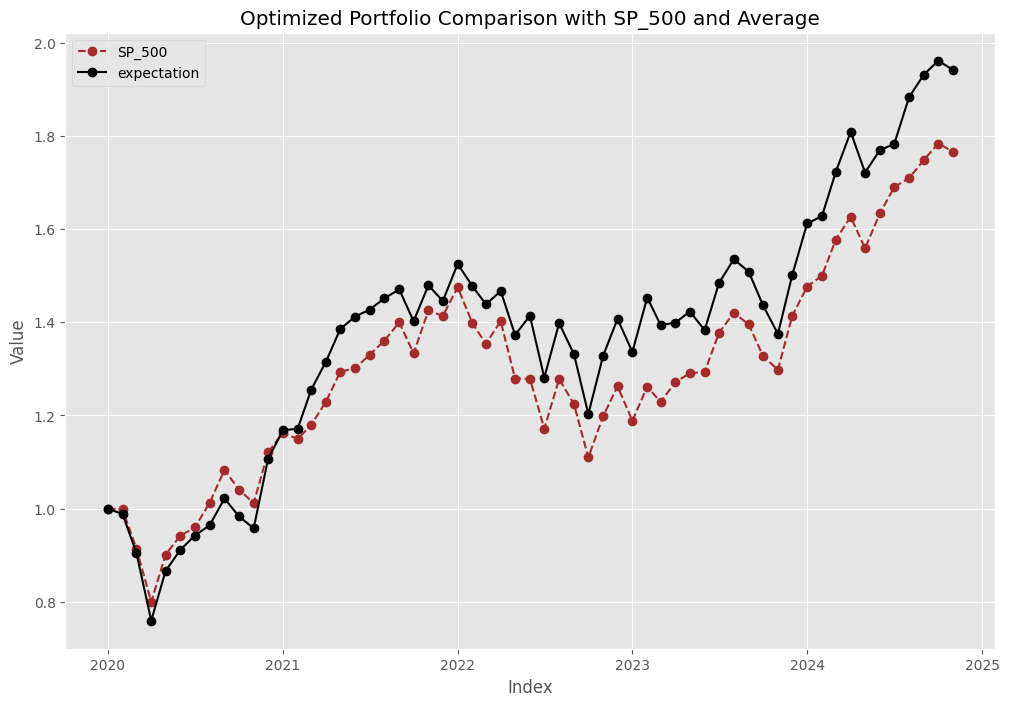

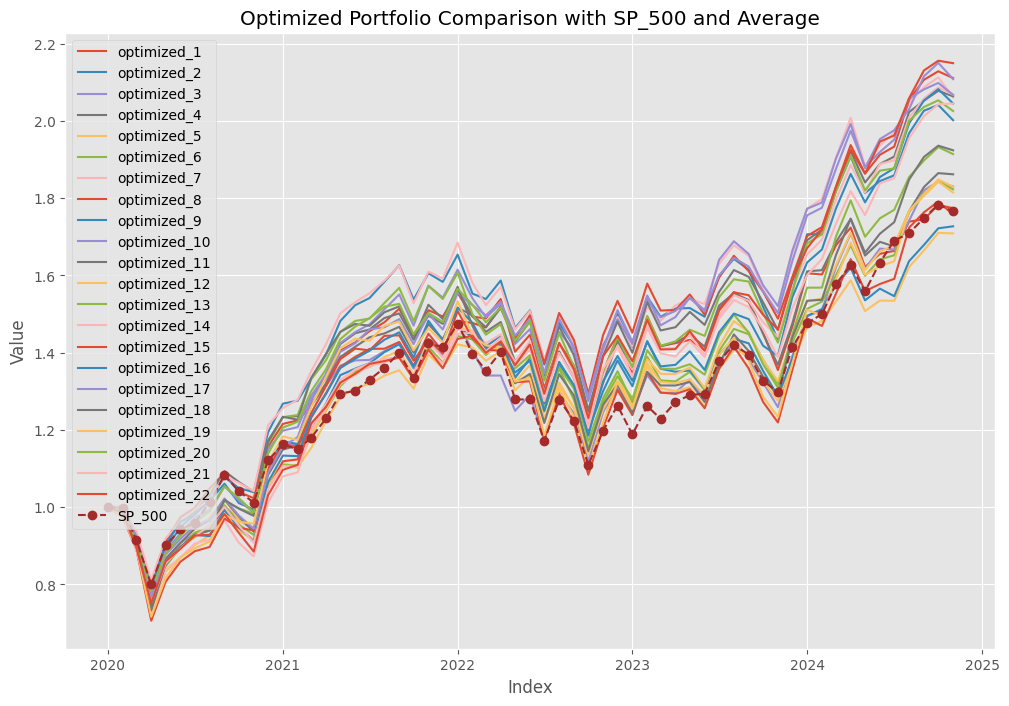

,SP_500,Optimized Portfolio
Date,,
2020-01-01,1.000000,1.000000
2020-02-01,0.998372,0.988722
2020-03-01,0.914398,0.905257
2020-04-01,0.799989,0.759532
2020-05-01,0.901463,0.866540
2020-06-01,0.942283,0.911789
2020-07-01,0.959610,0.942186
2020-08-01,1.012486,0.964386
2020-09-01,1.083426,1.021975


In [ ]:
avg_100=final_visual()#100
final_visual2()
final_visual1()
avg_100


In [ ]:
flist={}

In [ ]:
cumulative_exp_return,yoy_exp_return,sim_one_percentile=cumulative_returns_cal(oos1_list)
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')
print(cumulative_exp_return)
print(sim_one_percentile)
save_df_with_combination_to_excel(sim_one_percentile,'combination_data.xlsx','downside_protection',[1,0,0],7,0,0)
flist['0.810.3']=avg_100
yoy_exp_return

The sharpe ratio of the portfolio on average:0    0.637575
dtype: float64
The sharpe ratio of the sp500 : 0.5962030487382651
Year                2021       2022       2023       2024
Percentile                                               
99 percentile   9.659769  43.558761  37.794563  67.069362
Average        16.804372  52.509908  33.622121  61.204468
1 percentile   11.350681  42.171729  26.397493  46.566589
sp500          16.258923  47.524131  18.841269  47.637104
      1 percentile return in %
Year                          
1                         8.35
2                        25.78
3                       -20.82
4                        14.29
5                        11.54


,1,2,3,4,5
99th Percentile,26.57,35.10,-2.47,25.01,28.47
Median,16.37,30.37,-12.69,20.52,20.23
1st Percentile,8.35,25.78,-20.82,14.29,11.54
SP500,16.26,26.89,-19.44,24.23,19.62


In [ ]:
sharpe_simulation,sharpe_list_sim,sharpe_spy=list_sharpe_ratio(oos1_list)
print(f'The sharpe ratio of the portfolio on average:{sharpe_simulation}')
print(f'The sharpe ratio of the sp500 : {sharpe_spy}')


The sharpe ratio of the portfolio on average:0    0.809799
dtype: float64
The sharpe ratio of the sp500 : 0.66


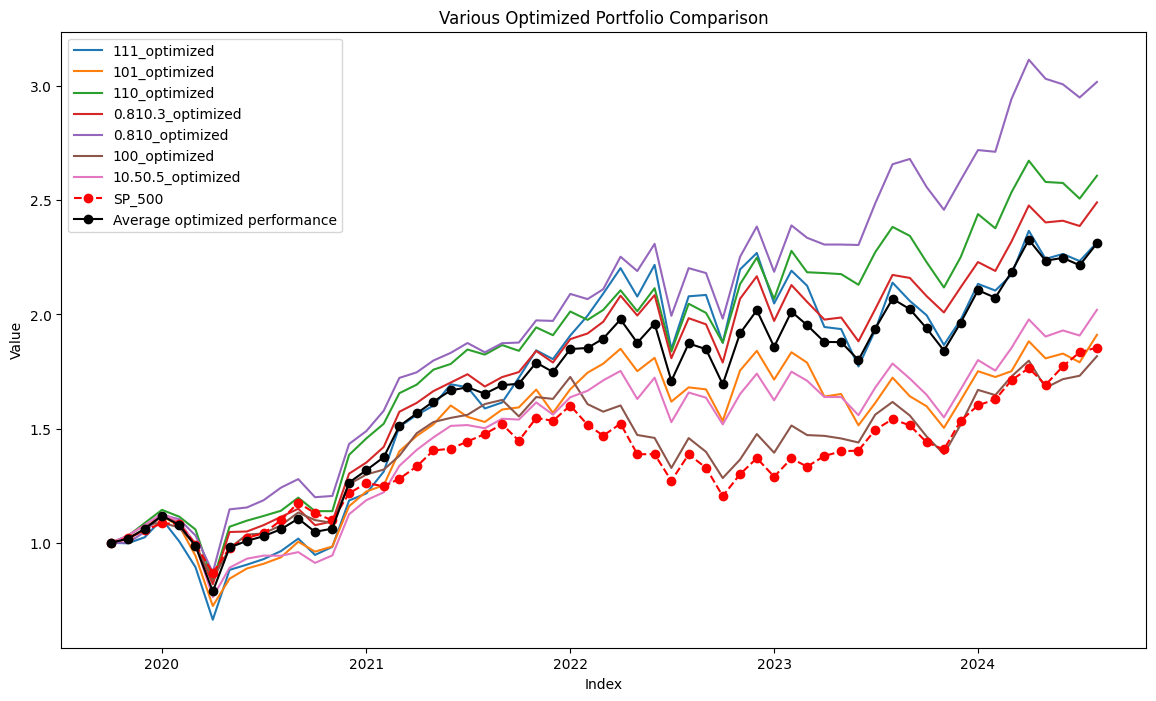

In [ ]:
finale_visual(flist)

# Saving analysis to excel sheet

In [ ]:
from openpyxl import Workbook
workbook_filename = 'combination_data.xlsx'
wb = Workbook()
wb.save(workbook_filename)


In [ ]:
save_df_with_combination_to_excel(sim_one_percentile,workbook_filename,'downside_protection',[1,0.75,0.5],0,0,0)

(1,)

In [ ]:
save_df_with_combination_to_excel(gdsk,workbook_filename,'downside_protection',['SP500','SP500','SP500'],1,0,0)

(2,)

In [ ]:
save_df_with_combination_to_excel(sim_one_percentile,workbook_filename,'downside_protection',[1,0.5,0.5],2,0,0)

(3,)

# Error checking area

In [ ]:
simulator(1,0,0,n_year_before,out_of_sample_year_end[2],upatebudget,50)
sjijas=out_of_sampless(out_of_sample_year_start[3],out_of_sample_year_end[3])
tostorelist.append(sjijas)
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000




Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
Column 'TPL' could not be converted to float.
True


KeyboardInterrupt: 

In [ ]:
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000

In [ ]:
simulator(1,0,0,n_year_before,n_year_after,1000000,50)
sjijas=out_of_sampless(out_of_sample_year_start[1],out_of_sample_year_end[1])
tostorelist.append(sjijas)
upatebudget=sjijas['Optimized Portfolio'][-1]*1000000




Column 'FOX' could not be converted to float.
Column 'FOXA' could not be converted to float.
True
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/d158aa235171444682b203a5a0404b18-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/d158aa235171444682b203a5a0404b18-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2316 COLUMNS
At line 41761 RHS
At line 44073 BOUNDS
At line 44521 ENDATA
Problem MODEL has 2311 rows, 2271 columns and 38514 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.07 seconds
Cgl0004I processed model has 968 rows, 1374 columns (446 integer (446 of which binary)) and 35752 elements
Cbc0038I Initial

In [ ]:
upatebudget

1272053.7273467889

In [ ]:
out_of_sample_year_end[2]

'2021-12-01'